# 3. Synthetic Populations and HDF5 I/O

If you are going to simulate the accretion of thousands of planets, using a `numpy` array is computationally vital. Additionally, `PA3Py` provides native methods to save the entire population to disk (`.h5`).

In [1]:
import sys
import os
import numpy as np
sys.path.insert(0, os.path.abspath('../../src'))
from pa3py import PA3Py

# Initialize the engine
sim = PA3Py('../../tests/test_data/run_smooth_a0.001_v10')

[load_tripodpy_hdf5] Reading 100 snapshots from ../../tests/test_data/run_smooth_a0.001_v10...


## Plotting the Hovmöller Diagram

Before placing embryos, it is useful to visualize the snowlines over the disk.

**Hovmöller Diagram Fields**
The `plot_hovmoller()` function supports three different fields for visualization. You can change them using the `field` argument:
* `field='dust_Sigma'` *(default)*: Displays the surface density of dust ($\Sigma_{\rm dust}$) in g/cm$^2$.
* `field='gas_Sigma'`: Displays the surface density of gas ($\Sigma_{\rm gas}$) in g/cm$^2$.
* `field='epsilon'`: Displays the dust-to-gas mass ratio ($\epsilon = \Sigma_{\rm dust} / \Sigma_{\rm gas}$).

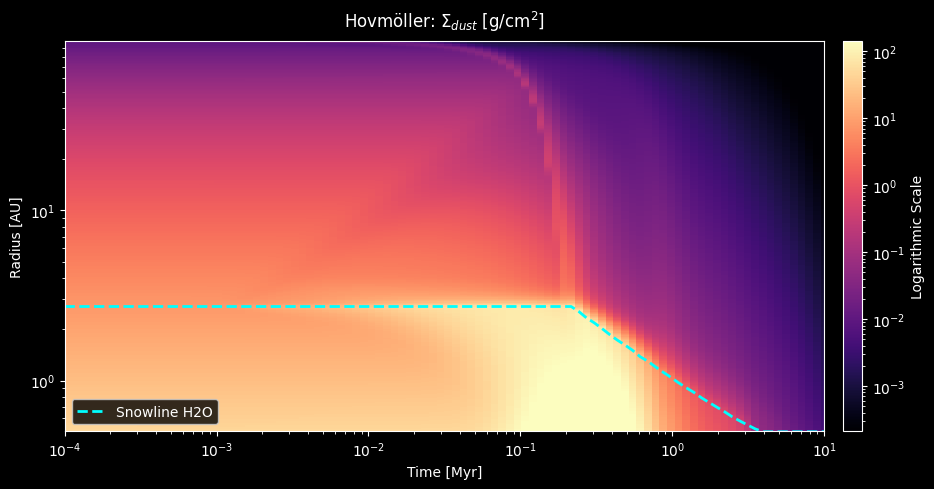

In [2]:
import matplotlib.pyplot as plt
sim.plot_hovmoller(field='dust_Sigma', show_snowlines=True)
plt.show()

## Defining the Synthetic Population

We will use `np.linspace` to generate 100 embryos along the disk.

In [3]:
# Important: to avoid infinite decimals (e.g. 1.98989), we use 99 points 
# for a range of 98 units (1 to 99) to ensure integer steps.
embryos = np.linspace(1.0, 10.0, 99).tolist()

# If you don't need to print the keys, using np.linspace(1, 99, 100) is perfectly valid.

print("Simulating", len(embryos), "embryos...")
results = sim.run_growth(embryos)

Simulating 99 embryos...

-------------------------------------------------------------
  r [AU]  M_tot [ME]  M_iso [ME]  f_silicates[%]  f_H2O[%]
-------------------------------------------------------------
    1.00        0.015         3.96            71.3      28.7
    1.09        0.018         4.22            67.6      32.4
    1.18        0.022         4.49            64.7      35.3
    1.28        0.029         4.75            61.2      38.8
    1.37        0.045         5.00            57.3      42.7
    1.46        0.071         5.25            54.1      45.9
    1.55        0.126         5.50            51.9      48.1
    1.64        0.174         5.74            51.2      48.8
    1.73        0.438         5.98            50.4      49.6
    1.83        0.151         6.21            51.3      48.7
    1.92        0.303         6.45            50.5      49.5
    2.01        0.477         6.68            52.3      47.7
    2.10        0.189         6.91            50.8      49.

C:\Users\Maxlo\AppData\Local\Temp\ipykernel_40752\670884697.py:3: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,15)


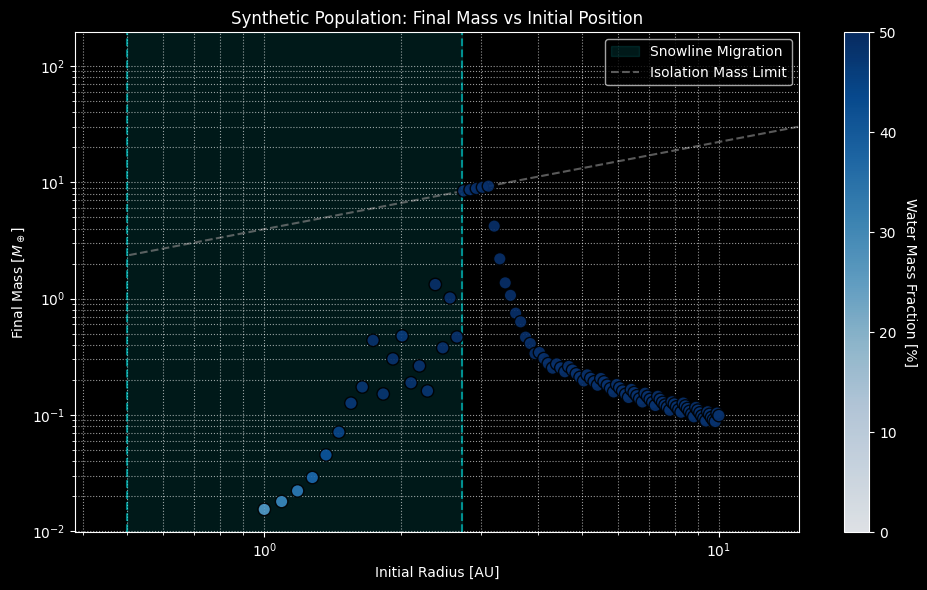

In [4]:
# Generar el gráfico completo de la población usando el método nativo
fig, ax = sim.plot_population(results)
plt.xlim(0,15)
plt.show()

## Saving Results (HDF5)

We will save the entire run to the hard drive.

In [5]:
sim.save_results(results, "synthetic_population_100.h5")
print("Data saved!")

Data saved!


## Loading Results

Tomorrow, when you open this notebook again, you won't have to re-run the physics.

In [6]:
# Load the matrix and also the list of chemistry used in that run
loaded_results, chemistry = PA3Py.load_results("synthetic_population_100.h5")

print("Species from the original simulation:", chemistry)
print("Loaded planets:", len(loaded_results))

Species from the original simulation: ['silicates', 'H2O']
Loaded planets: 99
